# ROI × Brain Mask Intersection — Pipeline-Matched Coverage

Assess ROI coverage using the **same logic** as `run_rsa_roi.py` and `run_decoding.py`:
resample each ROI to the subject's fMRIPrep functional brain mask (`learning1`),
then intersect `(roi > 0) & (brain_mask > 0)`.

Reports per-subject voxel counts for every mask in `masks/MNI152NLin2009cAsym/`
plus the visual cortex mask from the decoding pipeline.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn.image import resample_to_img, math_img
from nilearn.maskers import NiftiMasker

# ---------------------------------------------------------------------------
# Paths — cluster
# ---------------------------------------------------------------------------
BASE_DIR = Path("/home/hfluhr/data/learninghabits")
BIDS_DIR = Path("/home/hfluhr/shares-hare/ds-learning-habits/derivatives/fmriprep-24.0.1-noSDC")
MASK_DIR = BASE_DIR / "masks" / "MNI152NLin2009cAsym"
VIS_MASK = Path("/home/hfluhr/shares-hare/ds-learning-habits/derivatives/decoding/visual_cortex_mask.nii.gz")

REPO = Path("/home/hfluhr/repos/learning-habits-analysis")
sys.path.insert(0, str(REPO))
from utils.data import Subject

# Subject list
PARTICIPANTS = BASE_DIR / "participants_mvpa.tsv"
subjects = [line.strip() for line in PARTICIPANTS.read_text().splitlines() if line.strip()]
print(f"{len(subjects)} subjects from participants_mvpa.tsv")

59 subjects from participants_mvpa.tsv


## §1 — Load ROI masks

In [2]:
# Load all ROI masks from the masks directory + visual cortex from decoding
roi_paths = {}
for f in sorted(MASK_DIR.glob("*.nii*")):
    name = f.name.replace("_MNI152NLin2009cAsym.nii.gz", "").replace("_MNI152NLin2009cAsym.nii", "")
    roi_paths[name] = f

# Add visual cortex mask
roi_paths["visualcortex"] = VIS_MASK

# Load NIfTI images
roi_imgs = {}
for name, path in roi_paths.items():
    img = nib.load(str(path))
    if img.ndim == 4 and img.shape[3] == 1:
        from nilearn.image import index_img
        img = index_img(img, 0)
    roi_imgs[name] = img
    data = img.get_fdata()
    print(f"{name:40s}  shape={img.shape}  zooms={tuple(round(z,1) for z in img.header.get_zooms()[:3])}  "
          f"nonzero={int((data > 0).sum()):,}")

print(f"\n{len(roi_imgs)} ROI masks loaded")

fusiform_mask                             shape=(91, 109, 91)  zooms=(2.0, 2.0, 2.0)  nonzero=1,226
glm_chosen_peaks_spheres6mm               shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=58
habit_Guida2022                           shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=657
motor_HMAT                                shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=6,345
motor_M1only_HMAT                         shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=1,933
parietal_AAL                              shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=2,885
premotor_HMAT                             shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=4,412
putamen_AAL                               shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=500
striatum_bartra2013                       shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=128
vmpfc_bartra2013                          shape=(53, 65, 48)  zooms=(3.0, 3.0, 3.5)  nonzero=119
visualcortex        

## §2 — Per-subject intersection (pipeline-matched)

For each subject, load the fMRIPrep `learning1` brain mask (same as `run_rsa_roi.py` line 313),
resample each ROI with `nearest` interpolation, and compute `(roi > 0) & (brain_mask > 0)`.
Report the number of surviving voxels.

In [3]:
records = []
roi_names = list(roi_imgs.keys())

for sid in subjects:
    # Load brain mask exactly as the RSA pipeline does
    sub = Subject(base_dir=str(BASE_DIR), subject_id=sid,
                  include_imaging=True, bids_dir=str(BIDS_DIR))
    brain_mask_img = nib.load(sub.brain_mask['learning1'])
    brain_mask_data = brain_mask_img.get_fdata()
    n_brain = int((brain_mask_data > 0).sum())

    for roi_name, roi_img in roi_imgs.items():
        # Resample ROI to brain mask space (nearest), then intersect
        roi_func = resample_to_img(roi_img, brain_mask_img, interpolation='nearest')
        intersection = math_img('(v > 0) & (b > 0)', v=roi_func, b=brain_mask_img)
        n_voxels = int(intersection.get_fdata().sum())

        records.append({
            'subject': f"sub-{sid}",
            'roi': roi_name,
            'n_brain_voxels': n_brain,
            'n_roi_voxels': n_voxels,
            'frac_of_brain': n_voxels / n_brain if n_brain > 0 else 0.0,
        })

    print(f"  sub-{sid} done  (brain={n_brain:,} voxels)")

df = pd.DataFrame(records)
print(f"\n{len(df)} rows  ({len(subjects)} subjects × {len(roi_names)} ROIs)")

  sub-01 done  (brain=65,617 voxels)


  sub-02 done  (brain=62,791 voxels)


  sub-03 done  (brain=66,142 voxels)


  sub-05 done  (brain=65,393 voxels)


  sub-06 done  (brain=61,579 voxels)


...

  sub-69 done  (brain=62,811 voxels)


  sub-70 done  (brain=68,952 voxels)


  sub-71 done  (brain=63,933 voxels)


  sub-72 done  (brain=66,516 voxels)


  sub-73 done  (brain=63,127 voxels)

649 rows  (59 subjects × 11 ROIs)


## §3 — Summary table

In [4]:
summary = (df.groupby('roi')['n_roi_voxels']
           .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
           .sort_values('mean', ascending=False)
           .rename(columns={'count': 'n_sub'}))
summary[['mean', 'std', 'min', 'median', 'max']] = summary[['mean', 'std', 'min', 'median', 'max']].round(0).astype(int)

# Tag which ROIs are currently used in the RSA pipeline
rsa_rois = {'visualcortex', 'fusiform_mask', 'vmpfc_bartra2013', 'striatum_bartra2013'}
summary['in_RSA'] = ['✓' if r in rsa_rois else '' for r in summary.index]

print("Voxel counts after intersection with per-subject brain mask\n")
print(summary.to_string())

Voxel counts after intersection with per-subject brain mask

                             n_sub  mean  std   min  median   max in_RSA
roi                                                                     
visualcortex                    59  7599   71  7320    7600  7741      ✓
motor_HMAT                      59  6186   60  6023    6190  6339       
premotor_HMAT                   59  4335   32  4241    4334  4406       
parietal_AAL                    59  2859   25  2787    2866  2885       
motor_M1only_HMAT               59  1851   37  1738    1857  1933       
habit_Guida2022                 59   657    1   653     657   657       
putamen_AAL                     59   500    0   500     500   500       
fusiform_mask                   59   318    3   305     320   320      ✓
striatum_bartra2013             59   128    2   118     128   128      ✓
vmpfc_bartra2013                59   119    1   115     119   119      ✓
glm_chosen_peaks_spheres6mm     59    58    0    58      58    

## §4 — Per-subject voxel counts by ROI

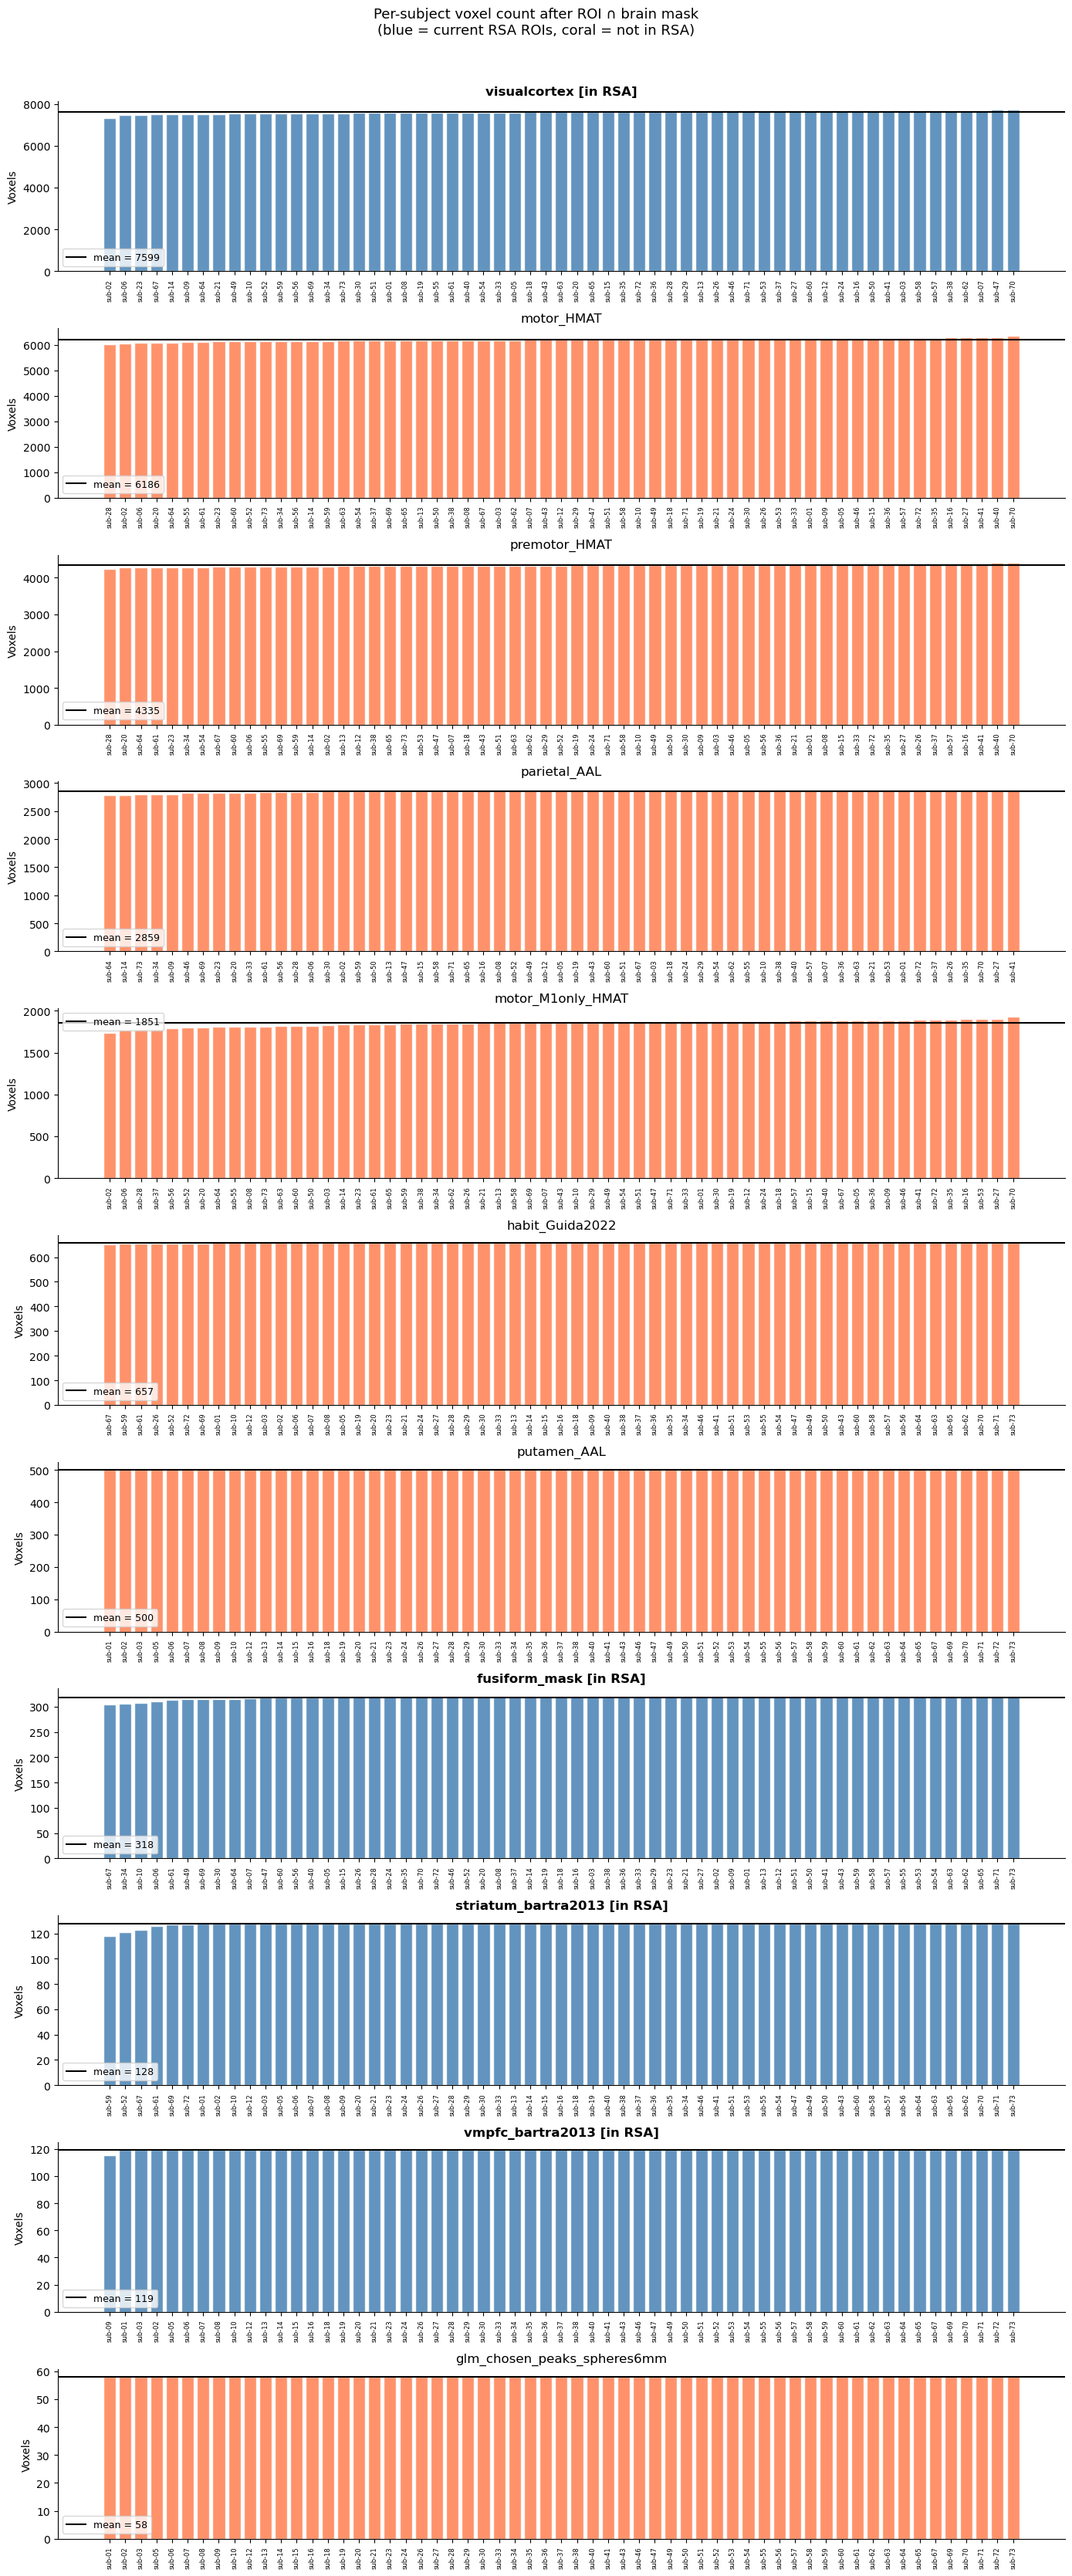

In [5]:
rois_sorted = summary.index.tolist()  # sorted by mean voxel count descending
n_rois = len(rois_sorted)

fig, axes = plt.subplots(n_rois, 1, figsize=(14, 3 * n_rois), sharex=False)
if n_rois == 1:
    axes = [axes]

for ax, roi_name in zip(axes, rois_sorted):
    df_roi = df[df['roi'] == roi_name].sort_values('n_roi_voxels')
    x = np.arange(len(df_roi))
    color = 'steelblue' if roi_name in rsa_rois else 'coral'
    ax.bar(x, df_roi['n_roi_voxels'], color=color, alpha=0.85, edgecolor='white')
    ax.axhline(df_roi['n_roi_voxels'].mean(), color='black', linewidth=1.5,
               label=f"mean = {df_roi['n_roi_voxels'].mean():.0f}")
    ax.set_xticks(x)
    ax.set_xticklabels(df_roi['subject'], rotation=90, fontsize=6)
    ax.set_ylabel('Voxels')
    tag = " [in RSA]" if roi_name in rsa_rois else ""
    ax.set_title(f"{roi_name}{tag}", fontweight='bold' if roi_name in rsa_rois else 'normal')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Per-subject voxel count after ROI ∩ brain mask\n(blue = current RSA ROIs, coral = not in RSA)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## §5 — Cross-subject variability (CV) and subjects with zero voxels

A high coefficient of variation flags ROIs that lose voxels inconsistently
across subjects (edge-of-brain or signal-dropout regions).

In [6]:
# CV and empty-mask check
cv = (df.groupby('roi')['n_roi_voxels']
      .agg(cv=lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan,
           n_empty=lambda x: (x == 0).sum())
      .sort_values('cv', ascending=False))
print("Coefficient of variation and subjects with 0 voxels:\n")
print(cv.round(3).to_string())

# Flag any subject × ROI with 0 voxels
empty = df[df['n_roi_voxels'] == 0]
if len(empty):
    print(f"\n⚠ {len(empty)} subject × ROI pairs have 0 voxels:")
    print(empty[['subject', 'roi']].to_string(index=False))
else:
    print("\n✓ No empty intersections across all subjects and ROIs.")

Coefficient of variation and subjects with 0 voxels:

                                cv  n_empty
roi                                        
motor_M1only_HMAT            0.020        0
striatum_bartra2013          0.013        0
fusiform_mask                0.011        0
motor_HMAT                   0.010        0
visualcortex                 0.009        0
parietal_AAL                 0.009        0
premotor_HMAT                0.007        0
vmpfc_bartra2013             0.004        0
habit_Guida2022              0.001        0
glm_chosen_peaks_spheres6mm  0.000        0
putamen_AAL                  0.000        0

✓ No empty intersections across all subjects and ROIs.


## §6 — Compact comparison: box plots

/tmp/ipykernel_101014/3487791210.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


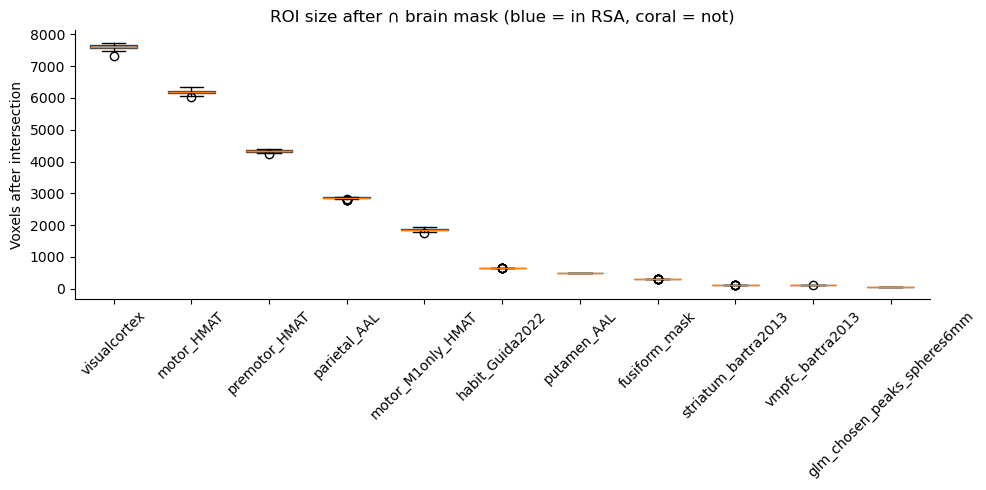

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
order = summary.index.tolist()  # descending mean voxel count
colors = ['steelblue' if r in rsa_rois else 'coral' for r in order]

bp = ax.boxplot(
    [df.loc[df['roi'] == r, 'n_roi_voxels'].values for r in order],
    labels=order, vert=True, patch_artist=True, widths=0.6,
)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.set_ylabel('Voxels after intersection')
ax.set_title('ROI size after ∩ brain mask (blue = in RSA, coral = not)')
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## §7 — ROI overlap matrix

Dice overlap between each pair of ROIs (computed on a representative subject)
to check for redundancy between masks.

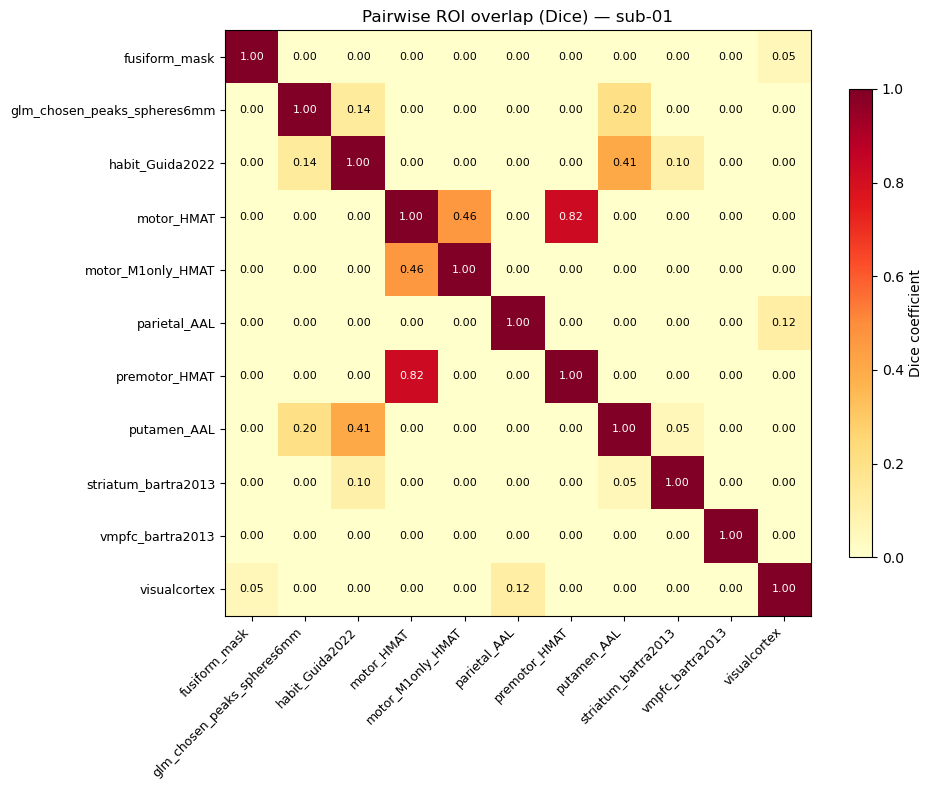


Pairs with Dice > 0.10:
  glm_chosen_peaks_spheres6mm    × habit_Guida2022                 Dice = 0.137
  glm_chosen_peaks_spheres6mm    × putamen_AAL                     Dice = 0.201
  habit_Guida2022                × putamen_AAL                     Dice = 0.406
  motor_HMAT                     × motor_M1only_HMAT               Dice = 0.462
  motor_HMAT                     × premotor_HMAT                   Dice = 0.823
  parietal_AAL                   × visualcortex                    Dice = 0.117


In [8]:
# Use first subject's brain mask as reference space
ref_sid = subjects[0]
ref_sub = Subject(base_dir=str(BASE_DIR), subject_id=ref_sid,
                  include_imaging=True, bids_dir=str(BIDS_DIR))
ref_brain = nib.load(ref_sub.brain_mask['learning1'])

# Resample all ROIs and intersect with brain mask
roi_binary = {}
for name, roi_img in roi_imgs.items():
    roi_func = resample_to_img(roi_img, ref_brain, interpolation='nearest')
    inter = math_img('(v > 0) & (b > 0)', v=roi_func, b=ref_brain)
    roi_binary[name] = inter.get_fdata().astype(bool)

# Dice coefficient matrix
names = list(roi_binary.keys())
n = len(names)
dice = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        a, b = roi_binary[names[i]], roi_binary[names[j]]
        intersection = (a & b).sum()
        dice[i, j] = 2 * intersection / (a.sum() + b.sum()) if (a.sum() + b.sum()) > 0 else 0

dice_df = pd.DataFrame(dice, index=names, columns=names).round(3)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dice, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n))
ax.set_yticklabels(names, fontsize=9)
for i in range(n):
    for j in range(n):
        color = 'white' if dice[i, j] > 0.5 else 'black'
        ax.text(j, i, f"{dice[i, j]:.2f}", ha='center', va='center', fontsize=8, color=color)
plt.colorbar(im, ax=ax, label='Dice coefficient', shrink=0.8)
ax.set_title(f"Pairwise ROI overlap (Dice) — sub-{ref_sid}")
plt.tight_layout()
plt.show()

# Print pairs with Dice > 0.1 (excluding self)
print("\nPairs with Dice > 0.10:")
for i in range(n):
    for j in range(i+1, n):
        if dice[i, j] > 0.10:
            print(f"  {names[i]:30s} × {names[j]:30s}  Dice = {dice[i,j]:.3f}")

## §8 — Glass-brain visualisation of all ROIs

All ROIs plotted on a single glass brain for spatial context.

/tmp/ipykernel_101014/1324903301.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


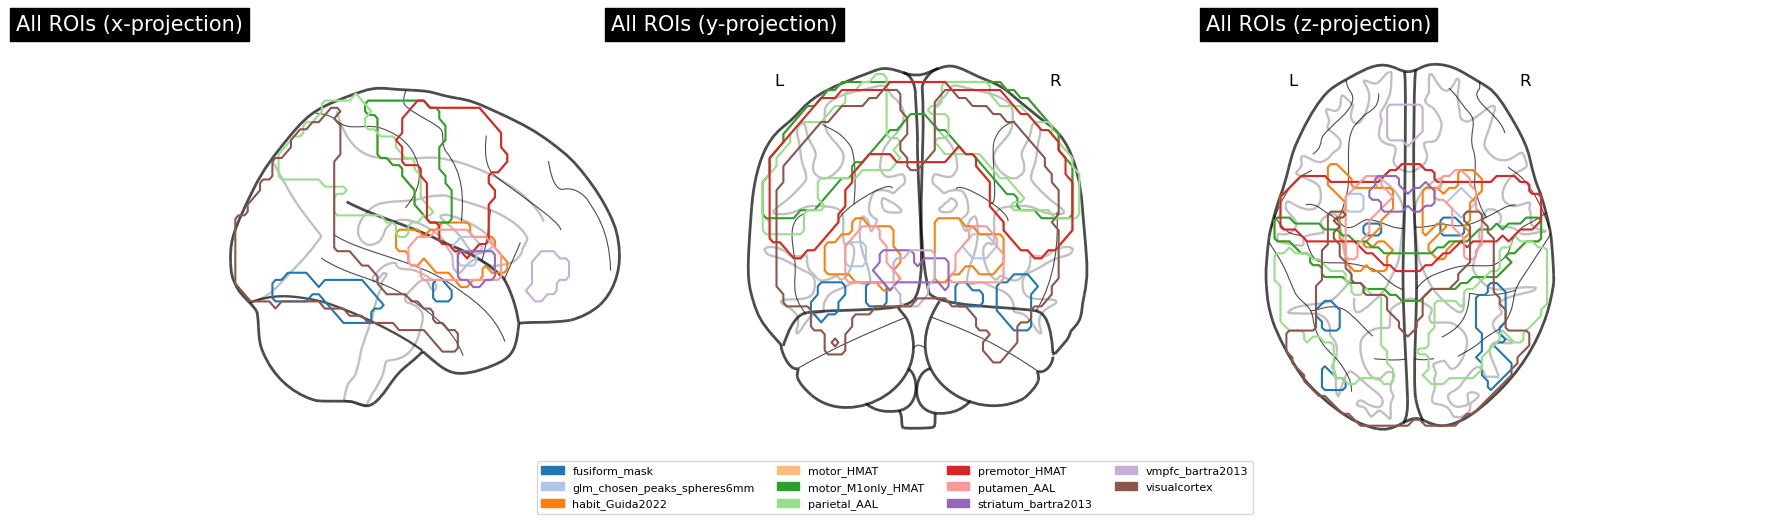

In [9]:
from nilearn import plotting
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Build a combined label volume: each ROI gets a unique integer
combined = np.zeros_like(list(roi_binary.values())[0], dtype=np.int16)
cmap_colors = plt.cm.tab20.colors[:len(names)]

for idx, name in enumerate(names, start=1):
    combined[roi_binary[name]] = idx

combined_img = nib.Nifti1Image(combined.astype(np.float32), ref_brain.affine)

# Plot each ROI as a separate contour on a glass brain
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': '3d'} if False else {})

for ax_idx, display_mode in enumerate(['x', 'y', 'z']):
    ax = axes[ax_idx]
    display = plotting.plot_glass_brain(None, display_mode=display_mode, axes=ax,
                                        title=f"All ROIs ({display_mode}-projection)")
    for idx, name in enumerate(names):
        roi_img = nib.Nifti1Image(roi_binary[name].astype(np.float32), ref_brain.affine)
        color = cmap_colors[idx % len(cmap_colors)]
        display.add_contours(roi_img, levels=[0.5], colors=[color], linewidths=1.5)

# Legend
patches = [mpatches.Patch(color=cmap_colors[i % len(cmap_colors)], label=n)
           for i, n in enumerate(names)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()